In [11]:
%pip install --pre torch torchvision torchaudio --index-url https://download.pytorch.org/whl/nightly/cu128 --no-cache-dir
%pip install -U FinanceDataReader 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import warnings, pickle
warnings.filterwarnings('ignore')


import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)


# 운영체제별 폰트 예외 처리 (Windows / Linux)
try:
    font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
    font_prop = fm.FontProperties(fname=font_path)
    plt.rcParams['font.family'] = font_prop.get_name()
except:
    plt.rcParams['font.family'] = 'Malgun Gothic'  # 로컬 윈도우 기본 폰트
plt.rcParams['axes.unicode_minus'] = False


from pykrx import stock
import yfinance as yf
from datetime import datetime, timedelta


from ta.momentum import RSIIndicator, StochasticOscillator
from ta.trend import MACD, EMAIndicator, SMAIndicator
from ta.volatility import BollingerBands, AverageTrueRange
from ta.volume import OnBalanceVolumeIndicator


from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import (accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, f1_score, roc_curve)
from sklearn.utils.class_weight import compute_class_weight
import lightgbm as lgb


# 🔥 PyTorch 핵심 컴포넌트 임포트
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader


# 🔥 로컬 GPU(RTX 5060 Ti) 장치 고정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ PyTorch    : {torch.__version__}')
print(f'✅ LightGBM   : {lgb.__version__}')
print(f'✅ Optuna     : {optuna.__version__}')
print(f'✅ GPU Device : {device} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None"})')


# =====================================================================

Looking in indexes: https://download.pytorch.org/whl/nightly/cu128
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
✅ PyTorch    : 2.12.0.dev20260408+cu128
✅ LightGBM   : 4.6.0
✅ Optuna     : 4.9.0
✅ GPU Device : cuda (NVIDIA GeForce RTX 5060 Ti)


ERROR: Could not find a version that satisfies the requirement FinanceDataReader (from versions: none)
ERROR: No matching distribution found for FinanceDataReader

[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
# =====================================================================
# ⚙️ Cell 3: 설정값 지정 (미장 전용)
# =====================================================================
import random
import datetime
import time
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import yfinance as yf
import lightgbm as lgb
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, confusion_matrix, roc_curve
from ta.momentum import RSIIndicator
from ta.trend import SMAIndicator, EMAIndicator, MACD
from ta.volatility import AverageTrueRange, BollingerBands
from ta.volume import OnBalanceVolumeIndicator

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

# 🎯 타겟 종목
TICKER     = 'NVDA'
START_DATE = '2015-01-01'
END_DATE   = datetime.datetime.today().strftime('%Y-%m-%d')

SEQ_LEN    = 60
PRED_DAYS  = 1
EPOCHS     = 200
TEST_RATIO = 0.15
VAL_RATIO  = 0.15
LSTM_UNITS = [64, 32]


# ✅ threshold 후보 (탐색용)
THRESHOLD_CANDIDATES = [0.001, 0.002, 0.003, 0.005, 0.008, 0.01]

# ✅ 가중치 초기값 (나중에 자동 최적화로 덮어씀)
W_LSTM = 0.33
W_LGBM = 0.33
W_RF   = 0.34

# PatchTST 하이퍼파라미터
PATCH_LEN = 10   # 패치 하나의 길이 (60일 / 10 = 6개 패치)
D_MODEL   = 64   # Transformer 임베딩 차원
N_HEADS   = 4    # Multi-head Attention 헤드 수
N_LAYERS  = 2    # Transformer 인코더 레이어 수

print(f'🔧 PatchTST 설정: PATCH_LEN={PATCH_LEN} | D_MODEL={D_MODEL} | N_HEADS={N_HEADS} | N_LAYERS={N_LAYERS}')
print(f'📌 미장 종목 티커 : {TICKER}')
print(f'📅 기간            : {START_DATE} ~ {END_DATE}')
print(f'🔮 예측 타겟       : 미래 {PRED_DAYS}영업일 뒤 방향성')
print(f'🎯 Threshold 후보  : {THRESHOLD_CANDIDATES}')

🔧 PatchTST 설정: PATCH_LEN=10 | D_MODEL=64 | N_HEADS=4 | N_LAYERS=2
📌 미장 종목 티커 : NVDA
📅 기간            : 2015-01-01 ~ 2026-07-15
🔮 예측 타겟       : 미래 1영업일 뒤 방향성
🎯 Threshold 후보  : [0.001, 0.002, 0.003, 0.005, 0.008, 0.01]


In [13]:
# =====================================================================
# 📥 Cell 4 & 5: 미장 데이터 + 거시경제 융합 및 피처 엔지니어링
# =====================================================================

def fetch_us_data(ticker, start, end):
    print(f'📡 {ticker} yfinance 주가 데이터 수집 중...')
    df = yf.download(ticker, start=start, end=end, progress=False)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df = df[['Open', 'High', 'Low', 'Close', 'Volume']]
    df.index = pd.to_datetime(df.index)
    df.dropna(inplace=True)
    print(f'✅ {ticker} 데이터 수집 완료! ({len(df)}일치)')
    return df, ticker

def fetch_external_data(start, end):
    print('📡 글로벌 거시경제 지수 동기화 중...')
    tickers = {
        'SP500' : '^GSPC',
        'NDX'   : '^NDX',
        'VIX'   : '^VIX',
        'DXY'   : 'DX-Y.NYB',
        'OIL'   : 'CL=F',
        'TNX'   : '^TNX',
    }
    ext = pd.DataFrame()
    for name, sym in tickers.items():
        try:
            data = yf.download(sym, start=start, end=end, progress=False)
            if isinstance(data.columns, pd.MultiIndex):
                data.columns = data.columns.get_level_values(0)
            ext[name] = data['Close']
        except:
            print(f'  ⚠️ {name} 다운로드 실패')
    ext.index = pd.to_datetime(ext.index)
    return ext

def add_features(df, threshold=0.01):
    d = df.copy()

    if 'SP500' in d.columns: d['SP500_return_1d'] = d['SP500'].pct_change().shift(1)
    if 'NDX' in d.columns:   d['NDX_return_1d']   = d['NDX'].pct_change().shift(1)
    if 'DXY' in d.columns:   d['DXY_return_1d']   = d['DXY'].pct_change().shift(1)
    if 'OIL' in d.columns:   d['OIL_return_1d']   = d['OIL'].pct_change().shift(1)
    if 'VIX' in d.columns:   d['VIX_diff_1d']     = d['VIX'].diff().shift(1)
    if 'TNX' in d.columns:   d['TNX_diff_1d']     = d['TNX'].diff().shift(1)

    d['Return'] = d['Close'].pct_change()
    for i in [2, 5, 10, 20]: d[f'Return_{i}d'] = d['Close'].pct_change(i)
    d['HL_ratio'] = (d['High'] - d['Low']) / d['Close']
    d['OC_ratio'] = (d['Close'] - d['Open']) / (d['Open'] + 1e-9)
    d['Gap'] = (d['Open'] - d['Close'].shift(1)) / (d['Close'].shift(1) + 1e-9)

    for w in [5, 10, 20, 60, 120]:
        sma = SMAIndicator(d['Close'], window=w).sma_indicator()
        d[f'SMA_{w}'] = sma
        d[f'SMA_dist_{w}'] = (d['Close'] - sma) / (sma + 1e-9)

    d['EMA_12'] = EMAIndicator(d['Close'], window=12).ema_indicator()
    d['EMA_26'] = EMAIndicator(d['Close'], window=26).ema_indicator()
    macd = MACD(d['Close'])
    d['MACD'], d['MACD_signal'], d['MACD_diff'] = macd.macd(), macd.macd_signal(), macd.macd_diff()

    for w in [7, 14, 21]: d[f'RSI_{w}'] = RSIIndicator(d['Close'], window=w).rsi()

    d['Volume_ratio'] = d['Volume'] / (d['Volume'].rolling(20).mean() + 1e-9)
    d['Vol_5d']  = d['Return'].rolling(5).std()
    d['Vol_20d'] = d['Return'].rolling(20).std()
    d['Vol_ratio'] = d['Vol_5d'] / (d['Vol_20d'] + 1e-9)

    if 'NDX_return_1d' in d.columns:
        d['TICKER_vs_NDX_1d'] = d['Return'].shift(1) - d['NDX_return_1d']

    raw_macro_cols = ['SP500', 'NDX', 'VIX', 'DXY', 'OIL', 'TNX']
    d = d.drop(columns=[col for col in raw_macro_cols if col in d.columns], errors='ignore')

    d['Future_Return'] = (d['Close'].shift(-PRED_DAYS) - d['Close']) / d['Close']
    d['Label'] = (d['Future_Return'] > threshold).astype(int)

    d.replace([np.inf, -np.inf], np.nan, inplace=True)
    return d.ffill().bfill().dropna()

# -----------------------------------------------------------------
# 🚀 데이터 수집 및 융합
# -----------------------------------------------------------------
df_raw, stock_name = fetch_us_data(TICKER, START_DATE, END_DATE)
df_ext = fetch_external_data(START_DATE, END_DATE)
df_merged = df_raw.join(df_ext, how='left').ffill().dropna()

print(f'✅ 원본 및 거시경제 지수 데이터 병합 완료! ({len(df_merged)}일치)')

📡 NVDA yfinance 주가 데이터 수집 중...
✅ NVDA 데이터 수집 완료! (2897일치)
📡 글로벌 거시경제 지수 동기화 중...
✅ 원본 및 거시경제 지수 데이터 병합 완료! (2897일치)


In [14]:
# =====================================================================
# ⚙️ Cell 6: 전처리 함수 정의 (threshold 인자 받는 구조)
# =====================================================================

EXCLUDE_COLS = ['Label','Open','High','Low','Close','Volume',
                'SP500','NDX','VIX','DXY','OIL','TNX','Future_Return']

def preprocess(df_merged, threshold):
    df_feat = add_features(df_merged, threshold=threshold)

    up_ratio = df_feat['Label'].mean()
    print(f'   threshold={threshold:.3f} | 상승={up_ratio*100:.1f}% | 하락={(1-up_ratio)*100:.1f}%')

    feature_cols = [c for c in df_feat.columns if c not in EXCLUDE_COLS]
    X_raw = df_feat[feature_cols].values
    y_raw = df_feat['Label'].values

    X_raw = np.where(np.isinf(X_raw), np.nan, X_raw)
    X_raw = pd.DataFrame(X_raw, columns=feature_cols).ffill().bfill().values

    n = len(X_raw)
    test_size = int(n * TEST_RATIO)
    val_size  = int(n * VAL_RATIO)
    train_size = n - test_size - val_size

    scaler = RobustScaler()
    X_tr_sc = scaler.fit_transform(X_raw[:train_size])
    X_vl_sc = scaler.transform(X_raw[train_size:train_size+val_size])
    X_te_sc = scaler.transform(X_raw[train_size+val_size:])

    y_train = y_raw[:train_size]
    y_val   = y_raw[train_size:train_size+val_size]
    y_test  = y_raw[train_size+val_size:]

    rf_sel = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf_sel.fit(X_tr_sc, y_train)
    selector = SelectFromModel(rf_sel, threshold='mean', prefit=True)

    X_tr_sel = selector.transform(X_tr_sc)
    X_vl_sel = selector.transform(X_vl_sc)
    X_te_sel = selector.transform(X_te_sc)

    def make_sequences(X, y, seq_len):
        xs, ys = [], []
        for i in range(seq_len, len(X)):
            xs.append(X[i-seq_len:i])
            ys.append(y[i])
        return np.array(xs), np.array(ys)

    X_tr, y_tr = make_sequences(X_tr_sel, y_train, SEQ_LEN)
    X_vl, y_vl = make_sequences(X_vl_sel, y_val,   SEQ_LEN)
    X_te, y_te = make_sequences(X_te_sel, y_test,  SEQ_LEN)

    X_tr_flat = X_tr[:, -1, :]
    X_vl_flat = X_vl[:, -1, :]
    X_te_flat = X_te[:, -1, :]

    return (df_feat, feature_cols, scaler, selector,
            X_tr, y_tr, X_vl, y_vl, X_te, y_te,
            X_tr_flat, X_vl_flat, X_te_flat)

print('✅ 전처리 함수 정의 완료!')

✅ 전처리 함수 정의 완료!


In [15]:
# =====================================================================
# 🤖 Cell 7: PatchTST 모델 정의
# =====================================================================

class PatchEmbedding(nn.Module):
    """시계열을 패치 단위로 쪼개서 임베딩"""
    def __init__(self, n_features, patch_len, d_model, dropout=0.1):
        super().__init__()
        self.patch_len  = patch_len
        self.projection = nn.Linear(patch_len * n_features, d_model)
        self.dropout    = nn.Dropout(dropout)
        self.norm       = nn.LayerNorm(d_model)

    def forward(self, x):
        # x: (batch, seq_len, n_features)
        B, L, F = x.shape
        n_patches = L // self.patch_len

        # 패치로 쪼개기
        x = x[:, :n_patches * self.patch_len, :]         # 딱 떨어지게 자르기
        x = x.reshape(B, n_patches, self.patch_len * F)  # (B, n_patches, patch_len*F)
        x = self.projection(x)                            # (B, n_patches, d_model)
        x = self.norm(x)
        return self.dropout(x)


class PatchTST(nn.Module):
    """PatchTST: 시계열 전용 Transformer"""
    def __init__(self, n_features, seq_len, patch_len=10,
                 d_model=64, n_heads=4, n_layers=2, dropout=0.3):
        super().__init__()
        self.patch_embedding = PatchEmbedding(n_features, patch_len, d_model, dropout)

        n_patches = seq_len // patch_len

        # Positional Encoding
        self.pos_encoding = nn.Parameter(torch.zeros(1, n_patches, d_model))
        nn.init.trunc_normal_(self.pos_encoding, std=0.02)

        # Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model    = d_model,
            nhead      = n_heads,
            dim_feedforward = d_model * 4,
            dropout    = dropout,
            batch_first = True,
            norm_first  = True      # Pre-LN → 학습 안정성 향상
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.norm        = nn.LayerNorm(d_model)

        # 분류 헤드
        self.head = nn.Sequential(
            nn.Linear(d_model * n_patches, 128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # 패치 임베딩
        x = self.patch_embedding(x)           # (B, n_patches, d_model)
        x = x + self.pos_encoding             # Positional Encoding 추가
        x = self.transformer(x)               # (B, n_patches, d_model)
        x = self.norm(x)
        x = x.flatten(1)                      # (B, n_patches * d_model)
        return self.head(x)                   # (B, 1)

print('✅ PatchTST 모델 정의 완료!')
print(f'   패치 수: {SEQ_LEN // PATCH_LEN}개 ({SEQ_LEN}일 / {PATCH_LEN}일)')
print(f'   d_model={D_MODEL} | n_heads={N_HEADS} | n_layers={N_LAYERS}')

✅ PatchTST 모델 정의 완료!
   패치 수: 6개 (60일 / 10일)
   d_model=64 | n_heads=4 | n_layers=2


In [16]:
# =====================================================================
# 🏋️ Cell 8: 학습 함수 + threshold 탐색 (LightGBM + RF만 사용)
# =====================================================================

def train_pytorch_engine(model, X_train, y_train, X_val, y_val,
                         epochs, batch_size, lr, class_weight, patience=15):
    X_tr_t = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_tr_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)
    X_vl_t = torch.tensor(X_val,   dtype=torch.float32).to(device)

    loader    = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=batch_size, shuffle=True)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)  # ✅ Adam → AdamW
    criterion = nn.BCELoss(reduction='none')

    # ✅ Warmup + CosineAnnealing 스케줄러 추가
    warmup_epochs = 10
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return epoch / warmup_epochs        # 천천히 LR 올리기
        return 0.5 * (1 + np.cos(              # 이후 코사인으로 감소
            np.pi * (epoch - warmup_epochs) / (epochs - warmup_epochs)
        ))
    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    best_auc, patience_counter, best_state = 0.0, 0, None
    w0, w1 = class_weight[0], class_weight[1]

    for epoch in range(epochs):
        model.train()
        train_probs, train_targets = [], []
        for bX, by in loader:
            optimizer.zero_grad()
            out  = model(bX)
            loss = (criterion(out, by) * (by*w1 + (1-by)*w0)).mean()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # ✅ Gradient Clipping 추가
            optimizer.step()
            train_probs.extend(out.detach().cpu().numpy())
            train_targets.extend(by.cpu().numpy())

        scheduler.step()  # ✅ 에폭마다 LR 업데이트

        model.eval()
        with torch.no_grad():
            val_out = model(X_vl_t).cpu().numpy()

        val_auc = roc_auc_score(y_val, val_out) if len(np.unique(y_val)) > 1 else 0.5

        if val_auc > best_auc:
            best_auc          = val_auc
            patience_counter  = 0
            best_state        = pickle.loads(pickle.dumps(model.state_dict()))
        else:
            patience_counter += 1
            if patience_counter >= patience: break

    if best_state: model.load_state_dict(best_state)
    return best_auc



# ✅ 1단계: threshold 탐색 (LightGBM + RF만, 빠르게)
print('🔍 1단계: Threshold 후보 탐색 중 (LightGBM + RF)...')
print('='*55)

threshold_scores = {}

for t in THRESHOLD_CANDIDATES:
    (df_feat_t, feature_cols_t, scaler_t, selector_t,
     X_tr_t, y_tr_t, X_vl_t, y_vl_t, X_te_t, y_te_t,
     X_tr_flat_t, X_vl_flat_t, X_te_flat_t) = preprocess(df_merged, threshold=t)

    up_ratio = y_tr_t.mean()
    if not (0.35 <= up_ratio <= 0.65):
        print(f'   threshold={t:.3f} → ⚠️ 스킵 (불균형 심함)\n')
        continue

    # LightGBM 빠른 학습
    lgb_temp = lgb.LGBMClassifier(
        n_estimators=300, learning_rate=0.05,
        class_weight='balanced', random_state=42, verbose=-1
    )
    lgb_temp.fit(X_tr_flat_t, y_tr_t,
                 eval_set=[(X_vl_flat_t, y_vl_t)],
                 callbacks=[lgb.early_stopping(20, verbose=False)])
    lgb_auc = roc_auc_score(y_vl_t, lgb_temp.predict_proba(X_vl_flat_t)[:, 1])

    # RF 빠른 학습
    rf_temp = RandomForestClassifier(
        n_estimators=200, max_depth=8,
        class_weight='balanced', random_state=42, n_jobs=-1
    )
    rf_temp.fit(X_tr_flat_t, y_tr_t)
    rf_auc = roc_auc_score(y_vl_t, rf_temp.predict_proba(X_vl_flat_t)[:, 1])

    avg_auc = (lgb_auc + rf_auc) / 2
    threshold_scores[t] = avg_auc
    print(f'   threshold={t:.3f} | LGB AUC={lgb_auc:.4f} | RF AUC={rf_auc:.4f} | 평균={avg_auc:.4f}')

BEST_THRESHOLD = max(threshold_scores, key=threshold_scores.get)
print('='*55)
print(f'\n✅ 최적 Threshold 확정: {BEST_THRESHOLD:.3f} (Val AUC={threshold_scores[BEST_THRESHOLD]:.4f})\n')

🔍 1단계: Threshold 후보 탐색 중 (LightGBM + RF)...
   threshold=0.001 | 상승=53.0% | 하락=47.0%
   threshold=0.001 | LGB AUC=0.5123 | RF AUC=0.5279 | 평균=0.5201
   threshold=0.002 | 상승=51.4% | 하락=48.6%
   threshold=0.002 | LGB AUC=0.4436 | RF AUC=0.5560 | 평균=0.4998
   threshold=0.003 | 상승=48.9% | 하락=51.1%
   threshold=0.003 | LGB AUC=0.5212 | RF AUC=0.5328 | 평균=0.5270
   threshold=0.005 | 상승=44.7% | 하락=55.3%
   threshold=0.005 | LGB AUC=0.5416 | RF AUC=0.5120 | 평균=0.5268
   threshold=0.008 | 상승=39.7% | 하락=60.3%
   threshold=0.008 | LGB AUC=0.5518 | RF AUC=0.5731 | 평균=0.5624
   threshold=0.010 | 상승=36.5% | 하락=63.5%
   threshold=0.010 | LGB AUC=0.5348 | RF AUC=0.5474 | 평균=0.5411

✅ 최적 Threshold 확정: 0.008 (Val AUC=0.5624)



In [17]:
# =====================================================================
# 🚀 Cell 9: 최적 Threshold로 전처리 + Optuna 하이퍼파라미터 탐색
# =====================================================================
print(f'🚀 2단계: threshold={BEST_THRESHOLD:.3f} 로 최종 학습 시작!')
print('='*55)

# 최적 threshold로 데이터 재생성
(df_feat, feature_cols, scaler, selector,
 X_tr, y_tr, X_vl, y_vl, X_te, y_te,
 X_tr_flat, X_vl_flat, X_te_flat) = preprocess(df_merged, threshold=BEST_THRESHOLD)

print(f'\n📊 최종 데이터 shape: Train={X_tr.shape} | Val={X_vl.shape} | Test={X_te.shape}')

# Optuna로 PatchTST 하이퍼파라미터 탐색
print('\n🔍 Optuna: PatchTST 최적 하이퍼파라미터 탐색 중...')

def patchtst_objective(trial):
    b_size    = trial.suggest_categorical('batch_size', [32, 64, 128])
    l_rate    = trial.suggest_float('lr', 1e-5, 1e-2, log=True)
    patch_len = trial.suggest_categorical('patch_len', [5, 10, 15])
    d_model   = trial.suggest_categorical('d_model', [32, 64, 128])
    n_heads   = trial.suggest_categorical('n_heads', [2, 4, 8])
    n_layers  = trial.suggest_int('n_layers', 1, 4)
    dropout   = trial.suggest_float('dropout', 0.1, 0.5)

    # n_heads가 d_model을 나눌 수 있어야 함
    if d_model % n_heads != 0:
        raise optuna.exceptions.TrialPruned()

    fold_scores = []
    total_len   = len(df_feat)
    n_splits    = 3
    fold_size   = total_len // (n_splits + 1)

    for fold in range(n_splits):
        train_end = fold_size * (fold + 1)
        test_end  = min(train_end + fold_size, total_len)
        if test_end - train_end < 10: continue

        df_train_fold = df_feat.iloc[:train_end]
        df_test_fold  = df_feat.iloc[train_end:test_end]
        v_idx = int(len(df_train_fold) * 0.9)

        Xtr_r = df_train_fold.iloc[:v_idx][feature_cols].values
        ytr_f = df_train_fold.iloc[:v_idx]['Label'].values
        Xvl_r = df_train_fold.iloc[v_idx:][feature_cols].values
        yvl_f = df_train_fold.iloc[v_idx:]['Label'].values
        Xte_r = df_test_fold[feature_cols].values
        yte_f = df_test_fold['Label'].values

        if any(len(a) <= SEQ_LEN for a in [Xtr_r, Xvl_r, Xte_r]): continue

        fs = RobustScaler()
        Xtr_sc = fs.fit_transform(Xtr_r)
        Xvl_sc = fs.transform(Xvl_r)
        Xte_sc = fs.transform(Xte_r)

        rf_fold = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
        rf_fold.fit(Xtr_sc, ytr_f)
        selector_fold = SelectFromModel(rf_fold, threshold='mean', prefit=True)

        Xtr_sel = selector_fold.transform(Xtr_sc)
        Xvl_sel = selector_fold.transform(Xvl_sc)
        Xte_sel = selector_fold.transform(Xte_sc)

        def make_sequences(X, y, seq_len):
            xs, ys = [], []
            for i in range(seq_len, len(X)):
                xs.append(X[i-seq_len:i])
                ys.append(y[i])
            return np.array(xs), np.array(ys)

        Xtr_s, ytr_s = make_sequences(Xtr_sel, ytr_f, SEQ_LEN)
        Xvl_s, yvl_s = make_sequences(Xvl_sel, yvl_f, SEQ_LEN)
        Xte_s, yte_s = make_sequences(Xte_sel, yte_f, SEQ_LEN)

        if any(len(a) == 0 for a in [Xtr_s, Xvl_s, Xte_s]): continue
        if any(len(np.unique(a)) < 2 for a in [ytr_s, yvl_s, yte_s]): continue

        # SEQ_LEN이 patch_len으로 나눠져야 함
        if SEQ_LEN % patch_len != 0:
            raise optuna.exceptions.TrialPruned()

        m = PatchTST(
            n_features = Xtr_s.shape[2],
            seq_len    = SEQ_LEN,
            patch_len  = patch_len,
            d_model    = d_model,
            n_heads    = n_heads,
            n_layers   = n_layers,
            dropout    = dropout
        ).to(device)

        cw = compute_class_weight('balanced', classes=np.array([0,1]), y=ytr_s)
        train_pytorch_engine(m, Xtr_s, ytr_s, Xvl_s, yvl_s,
                             epochs=15, batch_size=b_size, lr=l_rate,
                             class_weight={0:cw[0],1:cw[1]}, patience=4)

        m.eval()
        with torch.no_grad():
            preds = m(torch.tensor(Xte_s, dtype=torch.float32).to(device)).cpu().numpy().flatten()
        fold_scores.append(roc_auc_score(yte_s, preds))

    return np.mean(fold_scores) if fold_scores else 0.5

study_patchtst = optuna.create_study(direction='maximize')
study_patchtst.optimize(patchtst_objective, n_trials=20, show_progress_bar=True)

best = study_patchtst.best_params
FINAL_BATCH_SIZE    = best['batch_size']
FINAL_LEARNING_RATE = best['lr']
PATCH_LEN           = best['patch_len']
D_MODEL             = best['d_model']
N_HEADS             = best['n_heads']
N_LAYERS            = best['n_layers']

print(f'\n✅ Optuna 탐색 완료!')
print(f'   BATCH_SIZE={FINAL_BATCH_SIZE} | LR={FINAL_LEARNING_RATE:.6f}')
print(f'   PATCH_LEN={PATCH_LEN} | D_MODEL={D_MODEL} | N_HEADS={N_HEADS} | N_LAYERS={N_LAYERS}')
print(f'   Best AUC={study_patchtst.best_value:.4f}')

🚀 2단계: threshold=0.008 로 최종 학습 시작!
   threshold=0.008 | 상승=39.7% | 하락=60.3%

📊 최종 데이터 shape: Train=(1969, 60, 22) | Val=(374, 60, 22) | Test=(374, 60, 22)

🔍 Optuna: PatchTST 최적 하이퍼파라미터 탐색 중...


Best trial: 6. Best value: 0.520842: 100%|██████████| 20/20 [01:55<00:00,  5.76s/it]


✅ Optuna 탐색 완료!
   BATCH_SIZE=32 | LR=0.008358
   PATCH_LEN=5 | D_MODEL=128 | N_HEADS=8 | N_LAYERS=3
   Best AUC=0.5208


In [18]:
# =====================================================================
# 🏋️ Cell 10: 최종 LSTM + LightGBM + RF 학습
# =====================================================================
print('\n🏋️ 3단계: 최종 정밀 학습 시작...')

# LSTM
cw = compute_class_weight('balanced', classes=np.array([0,1]), y=y_tr)
class_weight = {0: cw[0], 1: cw[1]}
lstm_model = PatchTST(
    n_features = X_tr.shape[2],
    seq_len    = SEQ_LEN,
    patch_len  = PATCH_LEN,
    d_model    = D_MODEL,
    n_heads    = N_HEADS,
    n_layers   = N_LAYERS,
    dropout    = 0.3  # 👈 Dropout을 0.5로 상향하여 과적합 억제
).to(device)

train_pytorch_engine(lstm_model, X_tr, y_tr, X_vl, y_vl,
                     EPOCHS, FINAL_BATCH_SIZE, FINAL_LEARNING_RATE,
                     class_weight, patience=4)
print('✅ LSTM 학습 완료!')

# LightGBM + Optuna
print('\n🔍 Optuna LightGBM 튜닝 중...')
def objective(trial):
    params = {
        'n_estimators'    : trial.suggest_int('n_estimators', 300, 1000),
        'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth'       : trial.suggest_int('max_depth', 4, 8),
        'num_leaves'      : trial.suggest_int('num_leaves', 20, 60),
        'subsample'       : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'class_weight': 'balanced', 'random_state': 42, 'verbose': -1
    }
    m = lgb.LGBMClassifier(**params)
    m.fit(X_tr_flat, y_tr,
          eval_set=[(X_vl_flat, y_vl)],
          callbacks=[lgb.early_stopping(20, verbose=False)])
    return roc_auc_score(y_vl, m.predict_proba(X_vl_flat)[:, 1])

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10, show_progress_bar=False)
lgbm_model = lgb.LGBMClassifier(**study.best_params,
                                  class_weight='balanced', random_state=42, verbose=-1)
lgbm_model.fit(X_tr_flat, y_tr,
               eval_set=[(X_vl_flat, y_vl)],
               callbacks=[lgb.early_stopping(30, verbose=False)])
print(f'✅ LightGBM 완료! (Best AUC: {study.best_value:.4f})')

# RandomForest
print('\n🌳 RandomForest 학습 중...')
rf_model = RandomForestClassifier(
    n_estimators=500, max_depth=10,
    min_samples_split=10, min_samples_leaf=5,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf_model.fit(X_tr_flat, y_tr)
print('✅ RandomForest 완료!')

# =====================================================================
# 💾 모델 저장
# =====================================================================
import os
save_dir = f'./models/{TICKER}'
os.makedirs(save_dir, exist_ok=True)

# PyTorch 모델 저장
torch.save(lstm_model.state_dict(), f'{save_dir}/patchtst.pth')

# LightGBM, RF 저장
import pickle
with open(f'{save_dir}/lgbm.pkl', 'wb') as f:
    pickle.dump(lgbm_model, f)
with open(f'{save_dir}/rf.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

# 전처리 객체 저장 (scaler, selector, feature_cols)
meta = {
    'scaler'      : scaler,
    'selector'    : selector,
    'feature_cols': feature_cols,
    'BEST_THRESHOLD': BEST_THRESHOLD,
    'PATCH_LEN'   : PATCH_LEN,
    'D_MODEL'     : D_MODEL,
    'N_HEADS'     : N_HEADS,
    'N_LAYERS'    : N_LAYERS,
    'SEQ_LEN'     : SEQ_LEN,
    'W_LSTM'      : W_LSTM,
    'W_LGBM'      : W_LGBM,
    'W_RF'        : W_RF,
}
with open(f'{save_dir}/meta.pkl', 'wb') as f:
    pickle.dump(meta, f)

print(f'✅ 모델 저장 완료! → {save_dir}/')
print(f'   patchtst.pth | lgbm.pkl | rf.pkl | meta.pkl')


🏋️ 3단계: 최종 정밀 학습 시작...
✅ LSTM 학습 완료!

🔍 Optuna LightGBM 튜닝 중...
✅ LightGBM 완료! (Best AUC: 0.5678)

🌳 RandomForest 학습 중...
✅ RandomForest 완료!
✅ 모델 저장 완료! → ./models/NVDA/
   patchtst.pth | lgbm.pkl | rf.pkl | meta.pkl



⚖️ 4단계: 과적합 방지를 위한 1:1:1 균등 결합 적용 중...
✅ 최적 가중치 고정 완료! (정적 균등 결합)
   W_LSTM=0.34 | W_LGBM=0.33 | W_RF=0.33
   Validation AUC: 0.5801

        🔥 [최종 검증] 실전 투입 시 예상 성능 🔥
   * 진짜 Test AUC : 0.5277


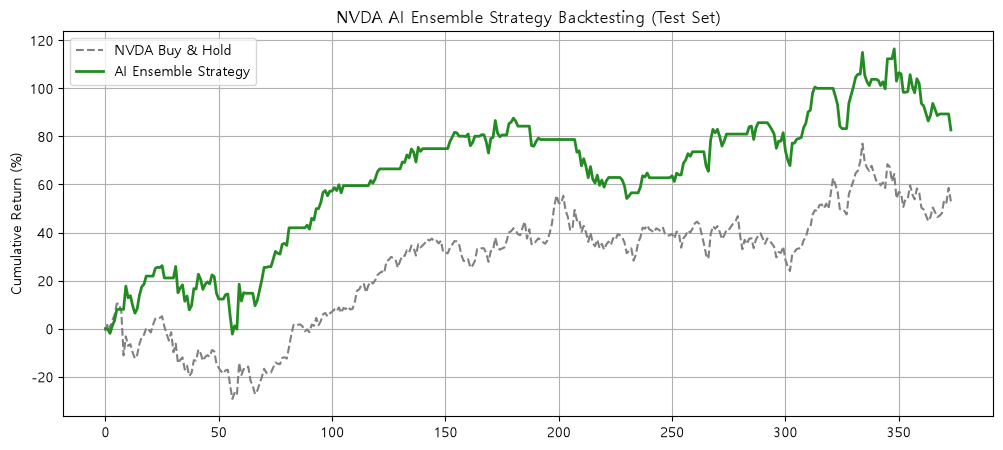

In [19]:
# =====================================================================
# ⚖️ Cell 11 (4단계): 과적합 제로! 1:1:1 균등 결합 (Hard-Coded Soft Voting)
# =====================================================================
print('\n⚖️ 4단계: 과적합 방지를 위한 1:1:1 균등 결합 적용 중...')

# 1. Validation 세트 예측 확률 추출
lstm_model.eval()
with torch.no_grad():
    lstm_prob_val = lstm_model(torch.tensor(X_vl, dtype=torch.float32).to(device)).cpu().numpy().flatten()
lgbm_prob_val = lgbm_model.predict_proba(X_vl_flat)[:, 1]
rf_prob_val   = rf_model.predict_proba(X_vl_flat)[:, 1]

# 2. Test 세트 예측 확률 추출
with torch.no_grad():
    lstm_prob_test = lstm_model(torch.tensor(X_te, dtype=torch.float32).to(device)).cpu().numpy().flatten()
lgbm_prob_test = lgbm_model.predict_proba(X_te_flat)[:, 1]
rf_prob_test   = rf_model.predict_proba(X_te_flat)[:, 1]

# 3. 가중치 고정
W_LSTM, W_LGBM, W_RF = 0.34, 0.33, 0.33
print(f'✅ 최적 가중치 고정 완료! (정적 균등 결합)')
print(f'   W_LSTM={W_LSTM:.2f} | W_LGBM={W_LGBM:.2f} | W_RF={W_RF:.2f}')

val_ens = W_LSTM*lstm_prob_val + W_LGBM*lgbm_prob_val + W_RF*rf_prob_val
val_auc = roc_auc_score(y_vl, val_ens)
print(f'   Validation AUC: {val_auc:.4f}')

# 4. 최종 Test 세트 결합 및 평가
final_test_ens = W_LSTM*lstm_prob_test + W_LGBM*lgbm_prob_test + W_RF*rf_prob_test
real_test_auc  = roc_auc_score(y_te, final_test_ens)

print("\n" + "="*55)
print(f"        🔥 [최종 검증] 실전 투입 시 예상 성능 🔥")
print("="*55)
print(f"   * 진짜 Test AUC : {real_test_auc:.4f}")
print("="*55)

# =====================================================================
# 🚀 ⚙️ 백테스팅 매매 로직 (숏 금지 + 현금 관망 + 5일 홀딩)
# =====================================================================
import matplotlib.pyplot as plt
test_returns = df_feat['Return'].iloc[-len(y_te):].values

strategy_signals = []
current_position = 0
hold_counter = 0
TARGET_THRESHOLD = BEST_THRESHOLD
HOLDING_DAYS = 5

for i in range(len(final_test_ens)):
    prob = final_test_ens[i]
    if current_position == 1:
        hold_counter -= 1
        if hold_counter == 0:
            current_position = 0
    if current_position == 0:
        if prob > (0.5 + TARGET_THRESHOLD):
            current_position = 1
            hold_counter = HOLDING_DAYS
        else:
            current_position = 0
    strategy_signals.append(current_position)

strategy_signals = np.array(strategy_signals)
shifted_signals = np.insert(strategy_signals[:-1], 0, 0)
strategy_returns = shifted_signals * test_returns

cum_market_returns   = np.cumprod(1 + test_returns) - 1
cum_strategy_returns = np.cumprod(1 + strategy_returns) - 1

line_color = 'forestgreen' if cum_strategy_returns[-1] > cum_market_returns[-1] else 'crimson'

plt.figure(figsize=(12, 5))
plt.plot(cum_market_returns * 100, label=f'{TICKER} Buy & Hold', color='gray', linestyle='--')
plt.plot(cum_strategy_returns * 100, label='AI Ensemble Strategy', color=line_color, linewidth=2)
plt.title(f'{TICKER} AI Ensemble Strategy Backtesting (Test Set)')
plt.ylabel('Cumulative Return (%)')
plt.legend()
plt.grid(True)
plt.show()

In [20]:
# =====================================================================
# 🔮 Cell 12: 실전 예측 대시보드 (헤지펀드 실전 가이드 적용)
# =====================================================================
def predict_latest_us(ticker=TICKER):
    df_new, nm   = fetch_us_data(ticker, START_DATE, END_DATE)
    df_ext_new   = fetch_external_data(START_DATE, END_DATE)
    df_f         = add_features(
                       df_new.join(df_ext_new, how='left').ffill().dropna(),
                       threshold=BEST_THRESHOLD            # ✅ 최적 threshold 사용
                   )
    X_new = np.where(np.isinf(df_f[feature_cols].values), np.nan, df_f[feature_cols].values)
    X_new = pd.DataFrame(X_new, columns=feature_cols).ffill().bfill().values
    X_new_sc  = scaler.transform(X_new)
    X_new_sel = selector.transform(X_new_sc)
    seq  = X_new_sel[-SEQ_LEN:][np.newaxis, ...]
    flat = X_new_sel[-1:, :]
    lstm_model.eval()
    with torch.no_grad():
        lp = lstm_model(
            torch.tensor(seq, dtype=torch.float32).to(device)
        ).cpu().numpy()[0][0]
    gp   = lgbm_model.predict_proba(flat)[0][1]
    rp   = rf_model.predict_proba(flat)[0][1]
    prob = W_LSTM*lp + W_LGBM*gp + W_RF*rp
     
    # -----------------------------------------------------------------
    # 🚀 [업그레이드 세팅] 매매 룰 마진 계산 및 시그널 강도 산출
    # -----------------------------------------------------------------
    TARGET_THRESHOLD = BEST_THRESHOLD # Cell 11 백테스팅 마진값과 동기화
    HOLDING_DAYS = 5         # 강제 홀딩 기간
    signal_strength = abs(prob - 0.5) * 200 # 0% ~ 100% 스케일 변환

    if prob > (0.5 + TARGET_THRESHOLD):
        decision = "🔥 강력 매수 (STRONG LONG)" if signal_strength > 15 else "📈 조건부 매수 (LONG)"
        action_plan = f"오늘 종가에 진입 후 최소 {HOLDING_DAYS}영업일 동안 무조건 홀딩 (잔파도 무시)"
    elif prob < (0.5 - TARGET_THRESHOLD):
        decision = "🚨 위험 감지: 현금 대피 (CASH OUT)"
        action_plan = f"신규 진입 절대 금지 및 기존 포지션 전량 현금화 후 관망"
    else:
        decision = "💤 방향성 불투명: 관망 (HOLD CASH)"
        action_plan = f"매수 마진(Threshold) 미달. 안전하게 현금 100% 쥐고 대기"

    print("\n" + "="*65)
    print(f" 🔮 PyTorch 앙상블 실전 매매 시그널 대시보드: {nm}")
    print("="*65)
    print(f" 📅 기준 거래일  : {df_f.index[-1].strftime('%Y-%m-%d')} (종가: ${df_f['Close'].iloc[-1]:.2f})")
    print(f" 🎯 타겟 예측    : 미래 {PRED_DAYS}영업일 뒤 방향성 (Threshold 마진: {TARGET_THRESHOLD})")
    print(f" 🛡️ 매매 룰 세팅 : 숏(인버스) 절대 금지 | 강제 홀딩 기간: {HOLDING_DAYS}일")
    print("-"*65)
    print(f" [모델 1] PyTorch LSTM   : {lp*100:.1f}% (Opinion: {'📈 BUY' if lp > 0.5 else '📉 CASH'})")
    print(f" [모델 2] LightGBM       : {gp*100:.1f}% (Opinion: {'📈 BUY' if gp > 0.5 else '📉 CASH'})")
    print(f" [모델 3] RandomForest   : {rp*100:.1f}% (Opinion: {'📈 BUY' if rp > 0.5 else '📉 CASH'})")
    print("─"*65)
    print(f" 🏆 앙상블 최종 결론 : {decision}")
    print(f" 📊 시그널 신뢰 강도 : {signal_strength:.1f}% (앙상블 확률: {prob*100:.1f}%)")
    print(f" 🎯 실전 매매 가이드 : {action_plan}")
    print("="*65)
    return prob

prob_final = predict_latest_us(TICKER)

📡 NVDA yfinance 주가 데이터 수집 중...
✅ NVDA 데이터 수집 완료! (2897일치)
📡 글로벌 거시경제 지수 동기화 중...

 🔮 PyTorch 앙상블 실전 매매 시그널 대시보드: NVDA
 📅 기준 거래일  : 2026-07-13 (종가: $203.53)
 🎯 타겟 예측    : 미래 1영업일 뒤 방향성 (Threshold 마진: 0.008)
 🛡️ 매매 룰 세팅 : 숏(인버스) 절대 금지 | 강제 홀딩 기간: 5일
-----------------------------------------------------------------
 [모델 1] PyTorch LSTM   : 51.7% (Opinion: 📈 BUY)
 [모델 2] LightGBM       : 42.0% (Opinion: 📉 CASH)
 [모델 3] RandomForest   : 43.5% (Opinion: 📉 CASH)
─────────────────────────────────────────────────────────────────
 🏆 앙상블 최종 결론 : 🚨 위험 감지: 현금 대피 (CASH OUT)
 📊 시그널 신뢰 강도 : 8.4% (앙상블 확률: 45.8%)
 🎯 실전 매매 가이드 : 신규 진입 절대 금지 및 기존 포지션 전량 현금화 후 관망
